# Анализ исторических данных РТО магазинов «Пятёрочка»

В этом блокноте проведем разведочный анализ данных (EDA), изучим структуру признаков, распределение целевой переменной (РТО) и динамику продаж во времени.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки визуализации
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## 1. Загрузка данных и первичный осмотр

In [4]:
data_path = 'train_2.csv'

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Файл не найден по пути: {data_path}")

df = pd.read_csv(data_path)
print(f"Размерность датасета: {df.shape[0]} строк, {df.shape[1]} признаков.")
df.head()

Размерность датасета: 485082 строк, 24 признаков.


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.00,16.00,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.00,16.00,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.00,16.00,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.00,16.00,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.00,16.00,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74209339.11


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485082 entries, 0 to 485081
Data columns (total 24 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     485082 non-null  int64  
 1   Год                                        485082 non-null  int64  
 2   Месяц                                      485082 non-null  int64  
 3   Среднее количество промо товаров в чеке    485082 non-null  float64
 4   Среднее количество товаров в чеке          485082 non-null  float64
 5   Среднее количество отмен                   485082 non-null  float64
 6   Рабочие часы в день                        485082 non-null  float64
 7   Дата открытия, категориальный              485082 non-null  object 
 8   Торговая площадь, категориальный           485082 non-null  object 
 9   Населенный пункт                           485082 non-null  object 
 10  Регион  

## 2. Анализ целевой переменной (РТО)

Проверим распределение целевой переменной, наличие аномалий, нулевых или отрицательных значений.

In [6]:
print("Описательные статистики целевой переменной (РТО):")
df['РТО'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

Описательные статистики целевой переменной (РТО):


count      485082.00
mean     88534798.92
std      48248998.21
min       1179116.01
1%       30796481.65
5%       39206282.46
25%      56272787.98
50%      75210937.85
75%     105767670.70
95%     185018583.89
99%     265394753.81
max     655720388.48
Name: РТО, dtype: float64

Количество нулевых значений РТО: 0
Количество отрицательных значений РТО: 0


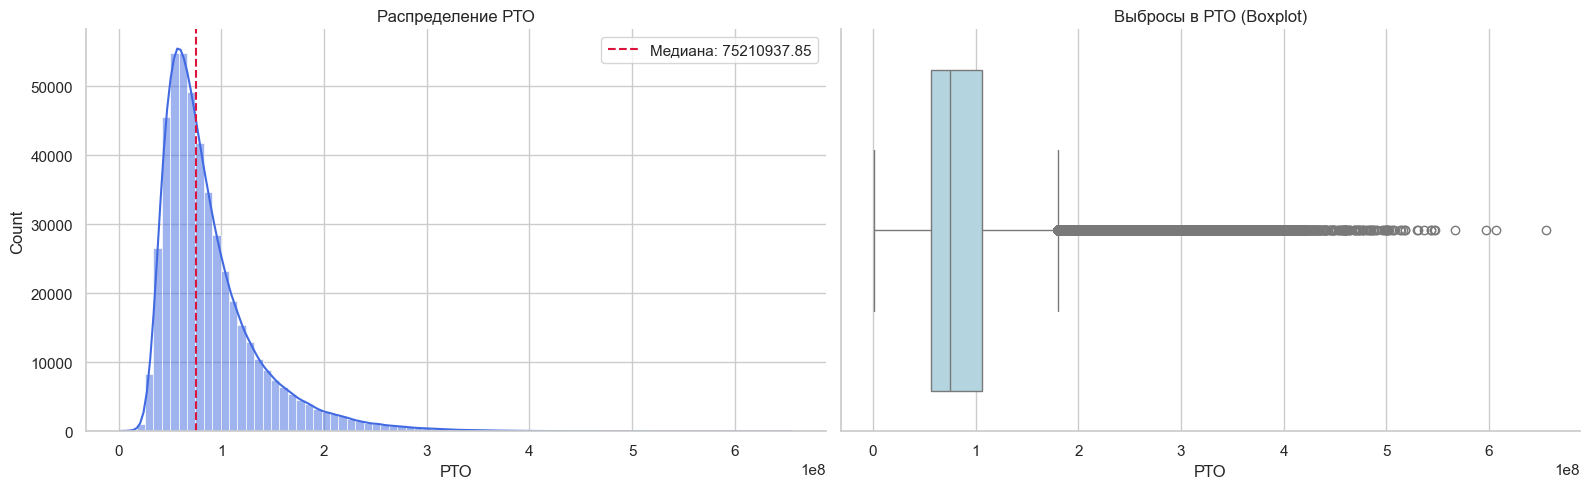

In [7]:
print(f"Количество нулевых значений РТО: {(df['РТО'] == 0).sum()}")
print(f"Количество отрицательных значений РТО: {(df['РТО'] < 0).sum()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Гистограмма распределения
sns.histplot(df['РТО'], bins=80, kde=True, ax=ax1, color='royalblue')
ax1.axvline(df['РТО'].median(), color='crimson', linestyle='--', label=f"Медиана: {df['РТО'].median():.2f}")
ax1.set_title('Распределение РТО')
ax1.legend()

# Ящик с усами
sns.boxplot(x=df['РТО'], ax=ax2, color='lightblue')
ax2.set_title('Выбросы в РТО (Boxplot)')

sns.despine()
plt.tight_layout()
plt.show()

## 3. Анализ структуры панели (магазины и время)

Выясним, является ли панель сбалансированной (одинаковое ли количество месяцев истории доступно для каждой торговой точки).

In [8]:
# Создаем единый признак даты
df['year_month'] = df['Год'].astype(str) + '-' + df['Месяц'].astype(str).str.zfill(2)
df['date'] = pd.to_datetime(df['year_month'] + '-01')

print(f"Уникальных магазинов в данных: {df['new_id'].nunique()}")
print(f"Временной диапазон: {df['date'].min().strftime('%Y-%m')} — {df['date'].max().strftime('%Y-%m')}")

# Количество периодов на один магазин
periods_per_store = df.groupby('new_id').size()
print("\nРаспределение количества доступных месяцев на магазин:")
periods_per_store.describe()

Уникальных магазинов в данных: 18657
Временной диапазон: 2023-01 — 2025-02

Распределение количества доступных месяцев на магазин:


count   18657.00
mean       26.00
std         0.00
min        26.00
25%        26.00
50%        26.00
75%        26.00
max        26.00
dtype: float64

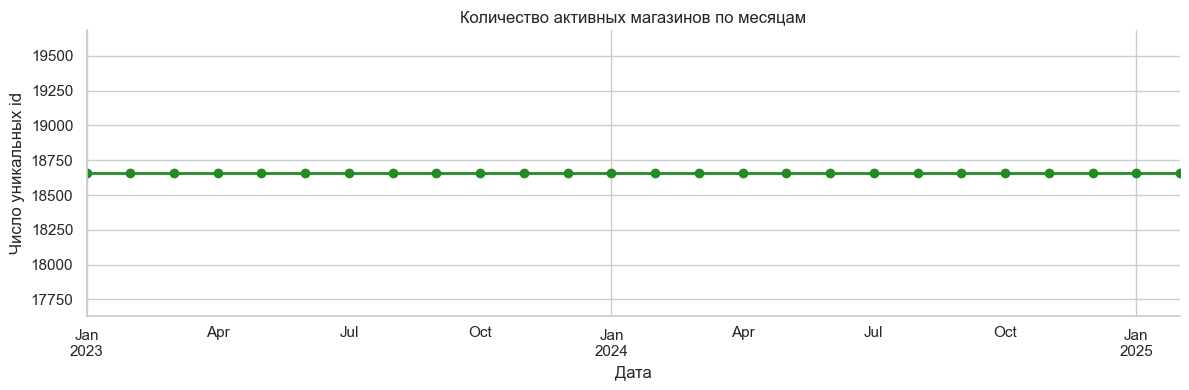

In [9]:
# Визуализируем динамику количества работающих магазинов по месяцам
active_stores = df.groupby('date')['new_id'].nunique()

plt.figure(figsize=(12, 4))
active_stores.plot(marker='o', color='forestgreen', linewidth=2)
plt.title('Количество активных магазинов по месяцам')
plt.xlabel('Дата')
plt.ylabel('Число уникальных id')
sns.despine()
plt.tight_layout()
plt.show()

## 4. Разделение признаков на статические и динамические

Для построения признаков важно понимать, какие характеристики магазина постоянны (например, регион или площадь), а какие меняются каждый месяц (характеристики чеков, трафик).

In [10]:
exclude_cols = ['new_id', 'Год', 'Месяц', 'year_month', 'date', 'РТО']
candidate_features = [col for col in df.columns if col not in exclude_cols]

static_feats = []
dynamic_feats = []

for col in candidate_features:
    # Если внутри одного магазина признак принимает только 1 уникальное значение, он статичен
    if (df.groupby('new_id')[col].nunique() == 1).all():
        static_feats.append(col)
    else:
        dynamic_feats.append(col)

print(f"Статические признаки (не меняются со временем): {len(static_feats)}")
print(static_feats)
print(f"\nДинамические признаки (изменяются ежемесячно): {len(dynamic_feats)}")
print(dynamic_feats)

Статические признаки (не меняются со временем): 17
['Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии']

Динамические признаки (изменяются ежемесячно): 3
['Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен']


## 5. Анализ пропусков в данных

In [11]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if missing_values.empty:
    print("Пропусков в датасете не обнаружено.")
else:
    print("Столбцы с пропущенными значениями:")
    print(missing_values)

Пропусков в датасете не обнаружено.


## 6. Временная динамика продаж по случайным магазинам

Посмотрим, как ведут себя временные ряды продаж на примере нескольких случайно выбранных торговых точек. Это поможет оценить масштаб сезонности и тренда.

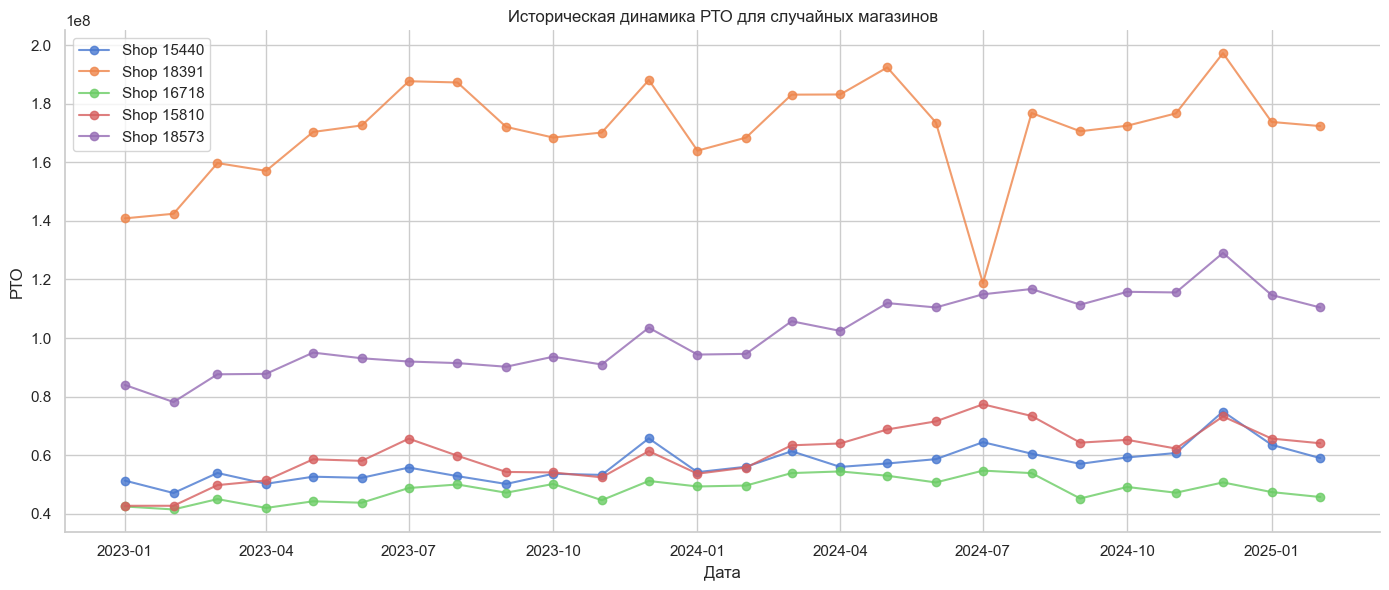

In [12]:
np.random.seed(42)  # Фиксируем seed для воспроизводимости графиков
random_shops = np.random.choice(df['new_id'].unique(), size=5, replace=False)

plt.figure(figsize=(14, 6))
for shop_id in random_shops:
    shop_data = df[df['new_id'] == shop_id].sort_values('date')
    plt.plot(shop_data['date'], shop_data['РТО'], marker='o', label=f"Shop {shop_id}", alpha=0.8)

plt.title('Историческая динамика РТО для случайных магазинов')
plt.xlabel('Дата')
plt.ylabel('РТО')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 7. Визуализация ошибок прогнозирования на валидации (февраль 2025)

*Примечание:* Данный блок кода используется для построения графиков ошибок на аномальных торговых точках по результатам работы скрипта постпроцессинга (выявление высокого уровня APE).

In [14]:
# Создаем директорию для сохранения графиков, если ее нет
os.makedirs('eda_outputs', exist_ok=True)

# Код ниже строит график для конкретного проблемного магазина.
# Он сохранен здесь как шаблон для выгрузки аналитических отчетов.

def plot_store_prediction_error(shop_id, history_df, actual_feb, pred_feb, ape_val):
    shop_history = history_df[history_df['new_id'] == shop_id].sort_values('time_idx').tail(13).copy()
    shop_history = shop_history.reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(10, 5.5))
    
    # Исторический тренд
    sns.lineplot(
        data=shop_history, 
        x='time_idx', 
        y='РТО', 
        marker='o', 
        ax=ax, 
        label='Реальные продажи', 
        color='royalblue', 
        linewidth=2
    )
    
    # Февральские точки
    feb_time_idx = 2025 * 12 + 2
    ax.scatter(feb_time_idx, actual_feb, color='forestgreen', s=120, zorder=5, label='Факт (февраль 2025)')
    ax.scatter(feb_time_idx, pred_feb, color='crimson', marker='X', s=150, zorder=5, label='Прогноз CatBoost')
    
    # Линия ошибки
    ax.vlines(
        x=feb_time_idx, 
        ymin=min(actual_feb, pred_feb), 
        ymax=max(actual_feb, pred_feb), 
        colors='dimgray', 
        linestyles='--', 
        linewidth=1.5, 
        label=f"Ошибка APE: {ape_val:.1f}%"
    )
    
    ax.set_title(f"Анализ ошибки прогноза: Магазин ID {shop_id}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Временной индекс")
    ax.set_ylabel("РТО")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)
    sns.despine()
    
    plt.tight_layout()
    plt.savefig(f'eda_outputs/error_analysis_shop_{shop_id}.png', dpi=150)
    plt.show()

print("Функция визуализации ошибок успешно инициализирована.")

Функция визуализации ошибок успешно инициализирована.
